Exemple de sintonització analítica d'un PD de 2n ordre
Sense la llibreria "control"
Implementació amb scipy.signal

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
SP = 5          # %
ts2 = 0.57      # s

t_ = np.arange(0, 1, 0.01)

# ---------------------------------------------------
# MODEL DEL MOTOR

# Gm(s) = 100 / ((1 + 0.1 s) s)

# Denominador:
# (1 + 0.1 s)s = 0.1 s² + s
# ---------------------------------------------------

num_Gm = [100]
den_Gm = [0.1, 1, 0]

Gm = signal.TransferFunction(num_Gm, den_Gm)

Resposta a esglaó en llaç obert

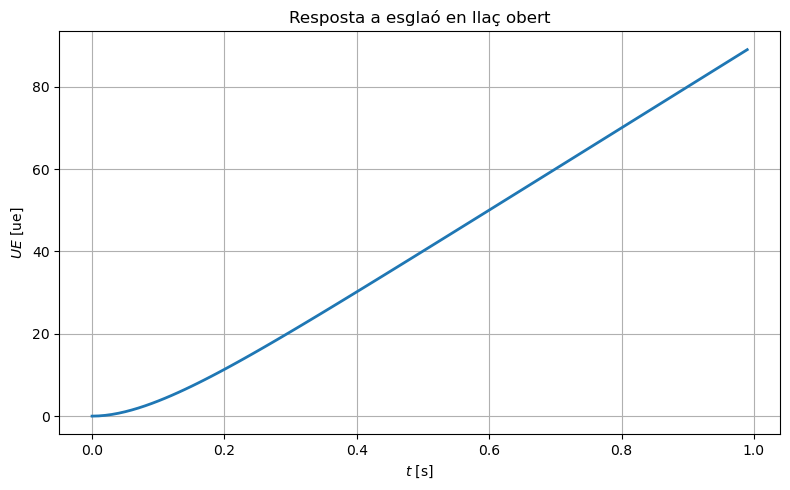

In [3]:
t_ol, y_ol = signal.step(Gm, T=t_)

plt.figure(figsize=(8,5))
plt.plot(t_ol, y_ol, linewidth=2)
plt.grid(True)
plt.title("Resposta a esglaó en llaç obert")
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"$UE$ [ue]")
plt.tight_layout()

Sintonització PD

In [4]:
A = ((np.log(100) - np.log(SP)) / np.pi)**2

zeta = np.sqrt(A / (1 + A))

omega_n = 4 / (zeta * ts2)

Kp = omega_n**2 / 1000
Kd = (2 * zeta * omega_n - 10) / 1000

print(f"ζ   = {zeta:.4f}")
print(f"ω_n = {omega_n:.4f}")
print(f"K_p = {Kp:.6f}")
print(f"K_d = {Kd:.6f}")

ζ   = 0.6901
ω_n = 10.1688
K_p = 0.103404
K_d = 0.004035


Controlador PD + G en llaç tancat

In [5]:
num_PD = [Kd, Kp]
den_PD = [1]

num_ol = np.polymul(num_PD, num_Gm)
den_ol = np.polymul(den_PD, den_Gm)

num_cl = num_ol
den_cl = np.polyadd(den_ol, num_ol)

Gcl = signal.TransferFunction(num_cl, den_cl)

Model ideal de segon ordre

In [6]:
num_cli = [1000 * Kp]
den_cli = [1, (10 + 1000 * Kd), 1000 * Kp]

Gcli = signal.TransferFunction(num_cli, den_cli)

Resposta temporal

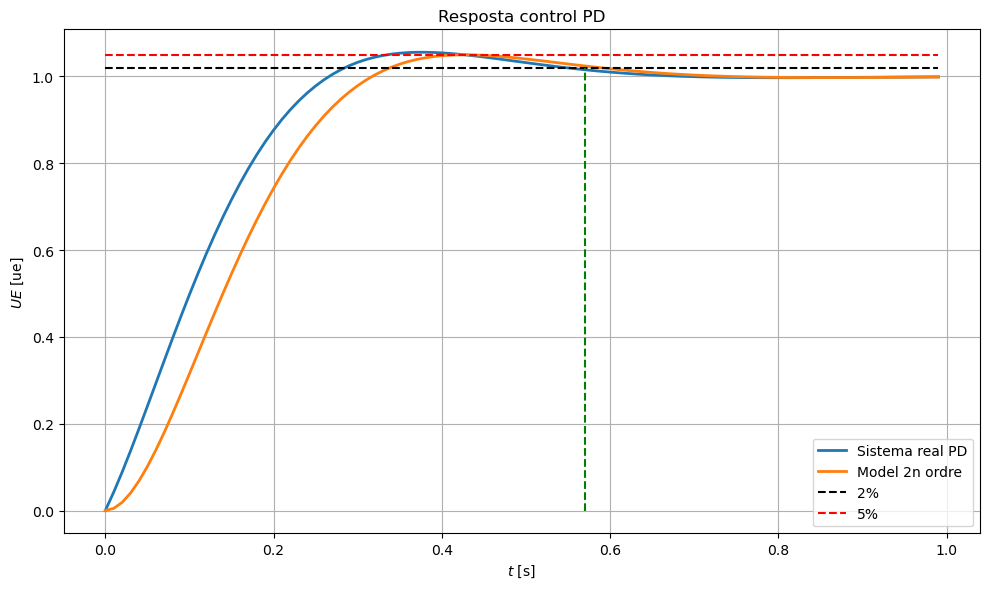

: 

In [ ]:
t_cl, y_cl = signal.step(Gcl, T=t_)
t_cli, y_cli = signal.step(Gcli, T=t_)

u02 = 1.02 * np.ones_like(t_)
u05 = 1.05 * np.ones_like(t_)

plt.figure(figsize=(10,6))

plt.plot(t_cl, y_cl, linewidth=2, label='Sistema real PD')
plt.plot(t_cli, y_cli, linewidth=2, label='Model 2n ordre')
plt.plot(t_, u02, 'k--', label='2%')
plt.plot(t_, u05, 'r--', label='5%')
plt.plot([ts2, ts2], [0, 1.02], 'g--')
plt.grid(True)
plt.title("Resposta control PD")
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"$UE$ [ue]")
plt.legend()
plt.tight_layout()

plt.show()